# Hospital Readmission Risk Analysis

## Exploratory Data Analysis (EDA)

Author: Dimitris Artinopoulos

Purpose:
Initial exploration of the synthetic hospital readmission dataset.

## 1. Import Libraries

In [4]:
import pandas as pd 

## 2. Load Dataset

In [5]:
df = pd.read_csv("../data/diabetic_data.csv")

## 3. Preview the Dataset

In [6]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


## 4. Understand the Dataset Structure

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      101766 non-null  str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    101766 non-null  str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                101766 non-null  str  
 11  medical_specialty         101766 non-null  str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medications           10176

### Observations

- The dataset contains 101,766 hospital encounters.
- It includes 50 features.
- There are 13 numerical and 37 categorical variables.
- The target variable appears to be 'readmitted'.
- Missing values are not detected automatically because some missing entries are likely stored as "?" strings.

## 5. Data Quality Assessment

In [8]:
df.isnull().sum()

encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                             0
weight                          0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                      0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

### Observations

- The dataset contains missing values.
- The largest number of missing values appears in 'max_glu_serum' and 'A1Cresult'.
- Most other variables are complete.
- Missing values may reflect that these laboratory tests were not performed for every patient.

In [9]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage.sort_values(ascending=False)

max_glu_serum               94.746772
A1Cresult                   83.277322
race                         0.000000
gender                       0.000000
age                          0.000000
weight                       0.000000
admission_type_id            0.000000
discharge_disposition_id     0.000000
admission_source_id          0.000000
time_in_hospital             0.000000
payer_code                   0.000000
medical_specialty            0.000000
num_lab_procedures           0.000000
num_procedures               0.000000
num_medications              0.000000
number_outpatient            0.000000
encounter_id                 0.000000
patient_nbr                  0.000000
number_inpatient             0.000000
number_emergency             0.000000
diag_1                       0.000000
diag_2                       0.000000
number_diagnoses             0.000000
diag_3                       0.000000
metformin                    0.000000
repaglinide                  0.000000
nateglinide 

### Observations

- 'max_glu_serum' has approximately 94.7% missing values.
- 'A1Cresult' has approximately 83.3% missing values.
- All remaining variables are complete.
- These missing values may indicate that these laboratory tests were not performed for most patients rather than representing data entry errors.

## 7. Explore the Target Variable

In [10]:
df["readmitted"].value_counts()

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

### Observations

- The target variable is `readmitted`.
- The dataset contains three classes:
  - `NO`
  - `>30`
  - `<30`
- Most patients were not readmitted.
- The `<30` category is the smallest and represents patients readmitted within 30 days.
- Predicting early readmission could help hospitals improve patient care and reduce healthcare costs.

## 8. Data Visualization

In [11]:
import matplotlib.pyplot as plt

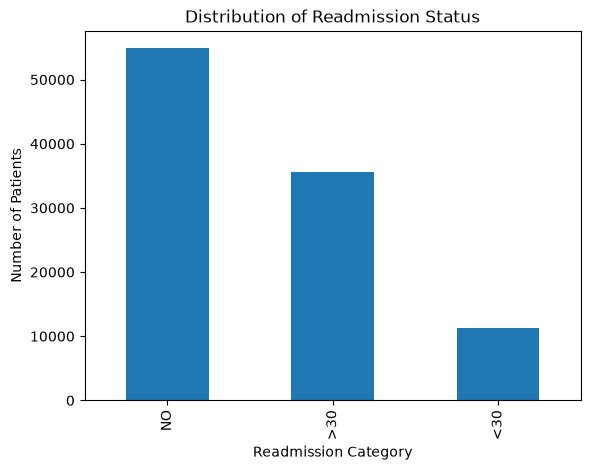

In [12]:
df["readmitted"].value_counts().plot(kind="bar")

plt.title("Distribution of Readmission Status")
plt.xlabel("Readmission Category")
plt.ylabel("Number of Patients")

plt.show()

### Observations

- Most patients were not readmitted.
- Patients readmitted within 30 days represent the smallest group.
- The target variable is imbalanced.
- This imbalance should be considered before training a machine learning model.

## 9. Explore Age Groups

In [13]:
df["age"].value_counts().sort_index()

age
[0-10)        161
[10-20)       691
[20-30)      1657
[30-40)      3775
[40-50)      9685
[50-60)     17256
[60-70)     22483
[70-80)     26068
[80-90)     17197
[90-100)     2793
Name: count, dtype: int64

### Observations

- Most hospital encounters involve older adults.
- The largest age group is 70–80 years.
- Very few hospital encounters involve children and young adults.
- The dataset is dominated by middle-aged and elderly patients.

## 10. Age Group vs Readmission

In [14]:
pd.crosstab(df["age"], df["readmitted"])

readmitted,<30,>30,NO
age,,,
[0-10),3,26,132
[10-20),40,224,427
[20-30),236,510,911
[30-40),424,1187,2164
[40-50),1027,3278,5380
[50-60),1668,5917,9671
[60-70),2502,7897,12084
[70-80),3069,9475,13524
[80-90),2078,6223,8896


## 11. Readmission Rate by Age Group

In [15]:
age_readmission = pd.crosstab(
    df["age"],
    df["readmitted"],
    normalize="index"
) * 100

age_readmission.round(1)

readmitted,<30,>30,NO
age,,,
[0-10),1.9,16.1,82.0
[10-20),5.8,32.4,61.8
[20-30),14.2,30.8,55.0
[30-40),11.2,31.4,57.3
[40-50),10.6,33.8,55.5
[50-60),9.7,34.3,56.0
[60-70),11.1,35.1,53.7
[70-80),11.8,36.3,51.9
[80-90),12.1,36.2,51.7


### Observations

- Patients aged 20–30 show the highest percentage of readmissions within 30 days (14.2%).
- Older age groups (70–90) have lower percentages of <30 readmissions than expected, but higher percentages of overall readmissions (>30 + <30).
- Young children (0–10) have the highest percentage of patients who were not readmitted.
- Absolute counts and percentages can lead to different conclusions, so both should be examined during exploratory data analysis.

## 12. Readmission Distribution by Age Group

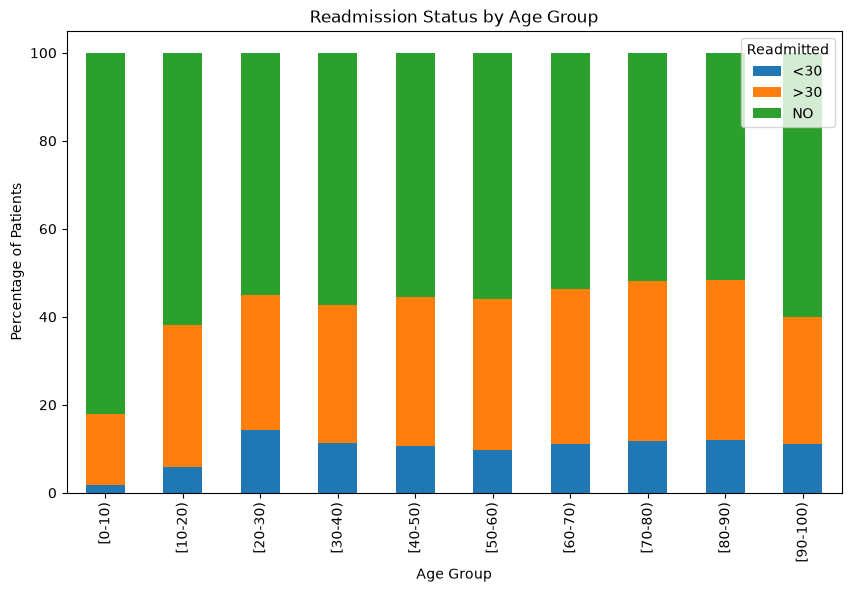

In [16]:
age_readmission.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Readmission Status by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Percentage of Patients")
plt.legend(title="Readmitted")

plt.show()

## 13. Professional Visualization with Matplotlib

### Create the chart using the Matplotlib Object-Oriented API

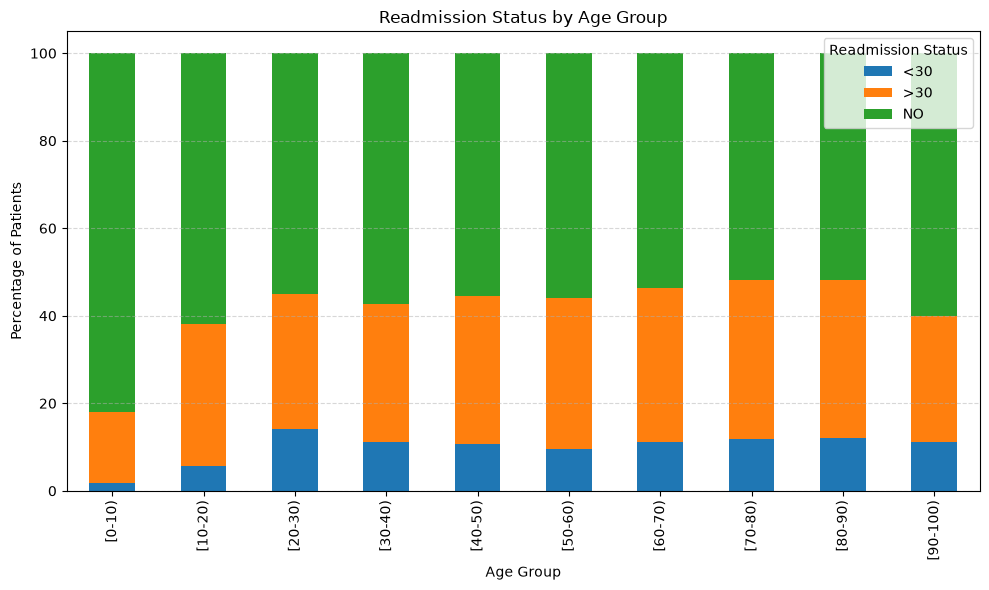

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))

age_readmission.plot(
    kind="bar",
    stacked=True,
    ax=ax
)

ax.set_title("Readmission Status by Age Group")
ax.set_xlabel("Age Group")
ax.set_ylabel("Percentage of Patients")

ax.legend(title="Readmission Status")

ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

fig.savefig(
    "../outputs/readmission_by_age.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()